In [1]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from matplotlib.lines import Line2D
from pandas.tseries.offsets import MonthEnd
from scipy.optimize import minimize
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error as root_mse

os.makedirs("output", exist_ok=True)
sns.set(style="white")

# Données

In [2]:
model_data_no_journal = pd.read_parquet("data/model_data_no_journal.parquet")
model_data = pd.read_parquet("data/model_data.parquet")

nuances_order = ["Far right", "Right", "Center", "Left", "Far left", "Other"]

In [3]:
presi_dates = [
    "26/04/1981", "10/05/1981",
    "24/04/1988", "08/05/1988",
    "23/04/1995", "07/05/1995",
    "21/04/2002", "05/05/2002",
    "22/04/2007", "06/05/2007",
    "22/04/2012", "06/05/2012",
    "21/04/2017", "07/05/2017",
    "10/04/2022", "24/04/2022"]
presi_months = pd.to_datetime(presi_dates, dayfirst=True).to_period('M').drop_duplicates()

legi_dates = [
    "14/06/1981", "21/06/1981",
    "16/03/1986",
    "05/06/1988", "11/06/1988",
    "21/03/1993", "28/03/1993",
    "25/05/1997", "01/06/1997",
    "09/06/2002", "16/06/2002",
    "10/06/2007", "17/06/2007",
    "10/06/2012", "17/06/2012",
    "11/06/2017", "18/06/2017",
    "12/06/2022", "19/06/2022",
    "29/06/2024", "06/07/2024"]
legi_months = pd.to_datetime(legi_dates, dayfirst=True).to_period('M').drop_duplicates()

regio_dates = [
    "16/03/1986",
    "22/03/1992",
    "15/03/1998",
    "21/03/2004", "28/03/2004",
    "14/03/2010", "21/03/2010",
    "06/12/2015", "13/12/2015",
    "20/06/2021", "27/06/2021"]
regio_months = pd.to_datetime(regio_dates, dayfirst=True).to_period('M').drop_duplicates()

canto_dates = [
    "14/03/1982", "21/03/1982",
    "10/03/1985", "17/03/1985",
    "25/09/1988", "02/10/1988",
    "20/03/1992", "27/03/1992",
    "15/03/1998", "22/03/1998",
    "11/03/2001", "18/03/2001",
    "21/03/2004", "28/03/2004",
    "9/03/2008", "16/03/2008",
    "20/03/2011", "27/03/2011"]
canto_months = pd.to_datetime(canto_dates, dayfirst=True).to_period('M').drop_duplicates()

dept_dates = [
    "22/03/2015", "29/03/2015",
    "20/06/2021", "27/06/2021"]
dept_months = pd.to_datetime(dept_dates, dayfirst=True).to_period('M').drop_duplicates()

muni_dates = [
    "06/03/1983", "13/03/1983",
    "12/03/1989", "19/03/1989",
    "11/06/1995", "18/06/1995",
    "11/03/2001", "18/03/2001",
    "09/03/2008", "16/03/2008",
    "23/03/2014", "30/03/2014",
    "15/03/2020", "28/06/2020"]
muni_months = pd.to_datetime(muni_dates, dayfirst=True).to_period('M').drop_duplicates()

europ_dates = [
    "17/06/1984",
    "18/06/1989",
    "12/06/1994",
    "13/06/1999",
    "13/06/2004",
    "07/06/2009",
    "25/05/2014",
    "26/05/2019",
    "09/06/2024"]
europ_months = pd.to_datetime(europ_dates, dayfirst=True).to_period('M').drop_duplicates()

main_elec_dates = presi_dates + legi_dates + europ_dates
main_elec_months = pd.to_datetime(main_elec_dates, dayfirst=True).to_period('M').drop_duplicates().sort_values()

other_elec_dates = regio_dates + canto_dates + dept_dates + muni_dates
other_elec_months = pd.to_datetime(other_elec_dates, dayfirst=True).to_period('M').drop_duplicates().sort_values()

def add_shaded_periods(ax_list, periods, color, alpha):
    start_period = None
    for i, period in enumerate(periods):
        if start_period is None:
            start_period = period
        is_last = (i == len(periods) - 1)
        is_gap = (not is_last and periods[i + 1] != period + 1)
        if is_last or is_gap:
            end_period = period
            start = start_period.to_timestamp()
            end = (end_period + MonthEnd(1)).to_timestamp()
            for ax in ax_list:
                ax.axvspan(start, end, color=color, alpha=alpha)
            start_period = None

# Méthode

**Période inter-électorale**
$$Y_{ijt}^{norm} = \alpha + (1 - n\alpha - \theta)(\beta {AN}_{it} + \gamma P_{it}) + \theta G_{it}$$

**Période pré-électorale (janvier-avril)**

On considère les sondages, en leur accordant un poids croissant à proximité de l'élection présidentielle (dont la distance au premier tour est reflétée par $e$).
$$Y_{ijt}^{norm} = \alpha + \delta_t^e \bigr[(1 - n\alpha - \theta)(\beta {AN}_{it} + \gamma P_{it}) + \theta G_{it}\bigr] + (1 - \delta_t^e) S_{it}$$

*Problème = tous choses égales par ailleurs, un parti améliorant son score à la présidentielle voit sa proportion normale se réduire, parce que les sièges à l'AN pèsent davantage dans le modèle. Ceci est bien visible en 1995 où l'élection présidentielle n'est pas suivie d'élections législatives. Essayer plutôt ceci ? En supposant que $delta^e=1$ en période pré-électorale et 0 sinon, et aussi que $gamma^e$ s'accroît au détriment de $\beta^e$ à l'approche des présidentielles.*Problème = tous choses égales par ailleurs, un parti améliorant son score à la présidentielle voit sa proportion normale se réduire, parce que les sièges à l'AN pèsent davantage dans le modèle. Ceci est bien visible en 1995 où l'élection présidentielle n'est pas suivie d'élections législatives. Essayer plutôt ceci ? En supposant que $delta^e=1$ en période pré-électorale et 0 sinon, et aussi que $gamma^e$ s'accroît au détriment de $\beta^e$ à l'approche des présidentielles.**

$$Y_{ijt}^{norm} = \alpha + (1 - n\alpha - \theta)\Bigr(\beta^e {AN}_{it} + \gamma^e \bigr(\delta^e P_{it} + (1 - \delta^e) S_{it}\bigr)\Bigr) + \theta G_{it}$$

**Période post-électorale (mai-juin)**

On considère seulement les résultats de l'élection présidentielle, en attendant ceux des législatives.

$$Y_{ijt}^{norm} = \alpha + (1 - n\alpha)P_{it}$$

*Problème = on utilise les résultats du T1, ce qui génère un biais en défaveur des partis accédant au second tour, et des sauts dans la courbe. Il vaudrait sans doute mieux utiliser les résultats du T2 pour la période post-électorale, avec un bonus fixe accordé au vainqueur (car les scores sont très proches).*

*Par exemple, en notant $P_{it}^{p1}$ la proportion des voix obtenues au premier tour et $P_{it}^{r2}$ l'indicatrice valant 1 si le parti $i$ est arrivé au rang $r$ au second tour.*

*Logiquement dans le mois de l'élection les 2 partis devraient être couverts à égalité.*

$$Y_{ijt}^{norm} = \alpha + (1 - n\alpha - \lambda_1 - \lambda_2)P_{it}^{p_1} + \sum_{r=1}^{2} \lambda_{r} P_{it}^{r_2}$$

Formellement, on note $D_t^e$ une indicatrice valant 1 si le mois $t$ se trouve en position $e$ dans le cycle électoral ($e \in [\text{inter}, \text{pre}-3, \text{pre}-2, \text{pre}-1, \text{pre}0, \text{post}]$). On estime alors :
$$Y_{ijt}^{norm} = \alpha + D_t^e \Bigr[\delta_t^e \bigr[(1 - n\alpha - \theta)(\beta^e {AN}_{it} + \gamma^e P_{it}) + \theta G_{it}\bigr] + (1 - \delta_t^e) S_{it}\Bigr]$$

In [4]:
outcome = "quotes_share"

alpha = 0
beta_inter = 0.7
beta_post = 0
gamma_inter = 0.3
gamma_post = 1
theta = 0.2

delta_inter = 1
delta_post = 1
delta_pre_3 = 0.85
delta_pre_2 = 0.7
delta_pre_1 = 0.5
delta_pre_0 = 0.2

lambda_1 = 0.3
lambda_2 = 0.2

n = len(model_data_no_journal['political_alignment'].unique())

In [5]:
ex_month = pd.Period('1995-6', freq='M')
vars = ["political_alignment", "na_share", "pres_votes_share", "r2_rank_1",  "r2_rank_2", "government", "pres_poll_result", 
        "inter_dum", "post_dum", "pre_3", "pre_2", "pre_1", "pre_0",
        outcome]
ex_data = model_data_no_journal[model_data_no_journal["month"] == ex_month][vars]

In [6]:
ex_data['y_norm'] = (
    alpha + 
    ex_data["inter_dum"] * (
        beta_inter * (1 - n*alpha - theta) * ex_data["na_share"] + 
        gamma_inter * (1 - n*alpha - theta) * ex_data["pres_votes_share"] +
        theta * ex_data["government"]) +
    ex_data["pre_3"] * (
        delta_pre_3 * (
            beta_inter * (1 - n*alpha - theta) * ex_data["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * ex_data["pres_votes_share"] +
            theta * ex_data["government"]) +
        (1 - delta_pre_3) * ex_data["pres_poll_result"]) +
    ex_data["pre_2"] * (
        delta_pre_2 * (
            beta_inter * (1 - n*alpha - theta) * ex_data["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * ex_data["pres_votes_share"] +
            theta * ex_data["government"]) +
        (1 - delta_pre_2) * ex_data["pres_poll_result"]) +
    ex_data["pre_1"] * (
        delta_pre_1 * (
            beta_inter * (1 - n*alpha - theta) * ex_data["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * ex_data["pres_votes_share"] +
            theta * ex_data["government"]) +
        (1 - delta_pre_1) * ex_data["pres_poll_result"]) +
    ex_data["pre_0"] * (
        delta_pre_0 * (
            beta_inter * (1 - n*alpha - theta) * ex_data["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * ex_data["pres_votes_share"] +
            theta * ex_data["government"]) +
        (1 - delta_pre_0) * ex_data["pres_poll_result"]) +
     ex_data["post_dum"] * (
         (1 - n*alpha - lambda_1 - lambda_2) * ex_data["pres_votes_share"] + 
         lambda_1 * ex_data['r2_rank_1'] + lambda_2 * ex_data['r2_rank_2'])
)

In [7]:
(1-0.2)*(0.7*0.818024+0.3*0.3649)+0.2

0.7456694399999999

In [8]:
(1-0.2)*(0.7*0.818024+0.3*(0.85*0.3649+0.15*0.460))+0.2

0.74909304

In [9]:
(1-0.2)*(0.6*0.818024+0.4*(0.7*0.3649+0.3*0.455))+0.2

0.71806912

In [10]:
model_data_no_journal[
    (model_data_no_journal['political_alignment'] == 'Right') &
    (model_data_no_journal["month"] >= pd.Period('1994-09', freq='M')) &
    (model_data_no_journal["month"] < pd.Period('1995-09', freq='M'))][
    ['month', "na_share", "pres_votes_share", "r2_rank_1", "r2_rank_2", "government", "pres_poll_result", 
     "inter_dum", "post_dum", "pre_3", "pre_2", "pre_1", "pre_0", 'y_norm']]

KeyError: "['y_norm'] not in index"

In [ ]:
     ex_data["post_dum"] * (
         beta_post * (1 - n*alpha) * ex_data["na_share"] + 
         gamma_post * (1 - n*alpha) * ex_data["pres_votes_share"])
)

In [11]:
ex_data['residual'] = ex_data[outcome] - ex_data['y_norm']
ex_data = ex_data.rename(columns={
    "quotes_share": "observed_quotes_share",
    "y_norm": "normal_quotes_share"})
ex_data["political_alignment"] = pd.Categorical(
    ex_data["political_alignment"],
    categories=nuances_order,
    ordered=True)
ex_data = ex_data.dropna(subset=['political_alignment']).reset_index(drop=True)
ex_data = ex_data.sort_values("political_alignment")

print("Regressors:")
print(f"- Sum of seats at National Assembly: {ex_data['na_share'].sum()}")
print(f"- Sum of votes at the last presidential election: {ex_data['pres_votes_share'].sum()}")
print("")
print(f"Observed and normal quotes share for {ex_month}:")
print(f"- Sum of observed values: {ex_data['observed_quotes_share'].sum()}")
print(f"- Sum of normal values: {ex_data['normal_quotes_share'].sum():.5f}")
print(f"- Sum of residuals: {ex_data['residual'].sum():.5f}")
print("")
ex_data.style.hide(axis=0).format(
    {col: "{:.3f}" for col in ex_data.columns if col != "political_alignment"})

Regressors:
- Sum of seats at National Assembly: 0.999999999966
- Sum of votes at the last presidential election: 1.0

Observed and normal quotes share for 1995-06:
- Sum of observed values: 1.0
- Sum of normal values: 1.00000
- Sum of residuals: 0.00000



political_alignment,na_share,pres_votes_share,r2_rank_1,r2_rank_2,government,pres_poll_result,inter_dum,post_dum,pre_3,pre_2,pre_1,pre_0,observed_quotes_share,normal_quotes_share,residual
Far right,0.000,0.197,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.089,0.047,0.042
Right,0.818,0.394,0.000,1.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.698,0.753,-0.055
Center,0.040,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.022,-0.022
Left,0.099,0.266,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.200,0.119,0.081
Far left,0.040,0.142,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.007,0.056,-0.049
Other,0.003,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.006,0.002,0.004


## Mesure de la distance entre les valeurs normales et observées

In [12]:
def mean_r(y_true, y_pred):
    return ((y_true - y_pred)).mean()

def mean_rr(y_true, y_pred):
    return (y_true / y_pred).mean()

# def mean_rr(y_true, y_pred):
#    return ((y_true - y_pred) / y_pred).mean()

def mean_ape(y_true, y_pred):
    return ((np.abs(y_true - y_pred) / y_pred).mean())

# Modèle normal

In [13]:
y_norm = (
    alpha + 
    model_data_no_journal["inter_dum"] * (
        beta_inter * (1 - n*alpha - theta) * model_data_no_journal["na_share"] + 
        gamma_inter * (1 - n*alpha - theta) * model_data_no_journal["pres_votes_share"] +
        theta * model_data_no_journal["government"]) +
    model_data_no_journal["pre_3"] * (
        delta_pre_3 * (
            beta_inter * (1 - n*alpha - theta) * model_data_no_journal["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * model_data_no_journal["pres_votes_share"] +
            theta * model_data_no_journal["government"]) +
        (1 - delta_pre_3) * model_data_no_journal["pres_poll_result"]) +
    model_data_no_journal["pre_2"] * (
        delta_pre_2 * (
            beta_inter * (1 - n*alpha - theta) * model_data_no_journal["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * model_data_no_journal["pres_votes_share"] +
            theta * model_data_no_journal["government"]) +
        (1 - delta_pre_2) * model_data_no_journal["pres_poll_result"]) +
    model_data_no_journal["pre_1"] * (
        delta_pre_1 * (
            beta_inter * (1 - n*alpha - theta) * model_data_no_journal["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * model_data_no_journal["pres_votes_share"] +
            theta * model_data_no_journal["government"]) +
        (1 - delta_pre_1) * model_data_no_journal["pres_poll_result"]) +
    model_data_no_journal["pre_0"] * (
        delta_pre_0 * (
            beta_inter * (1 - n*alpha - theta) * model_data_no_journal["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * model_data_no_journal["pres_votes_share"] +
            theta * model_data_no_journal["government"]) +
        (1 - delta_pre_0) * model_data_no_journal["pres_poll_result"]) +
     model_data_no_journal["post_dum"] * (
         (1 - n*alpha - lambda_1 - lambda_2) * model_data_no_journal["pres_votes_share"] + 
         lambda_1 * model_data_no_journal['r2_rank_1'] + lambda_2 * model_data_no_journal['r2_rank_2'])
)

In [14]:
y = model_data_no_journal[outcome]

r2 = r2_score(y, y_norm)
mr = mean_r(y, y_norm)
mrr = mean_rr(y, y_norm)
mape = mean_ape(y, y_norm)
rmspe = root_mse(y, y_norm)

print(f"R2: {100*r2:.2f}%")
print(f"MR: {100*mr:.2f}%")
print(f"MRR: {100*mrr:.2f}%")
print(f"MAPE: {100*mape:.2f}%")
print(f"RMSPE: {rmspe:.5f}")

R2: 83.81%
MR: 0.44%
MRR: inf%
MAPE: inf%
RMSPE: 0.09053


<span style="background-color: yellow">*Commentaire*</span>

Les résidus moyens ne sont pas nuls donc le modèle n'est pas centré comme avec une régression ordinaire, il reste un biais systématique des prévisions, légèrement inférieures en moyenne aux valeurs réelles (de 2 points de pourcentage)

Résidus relatifs moyens négatifs = le biais n'est pas identique selon la distribution des valeurs normales. Il est négatif lorsque les valeurs normales sont importantes, mais positifs lorsque les valeurs normales sont faibles. Or la normalisation fait que les valeurs normales faibles pèsent davantage sur la moyenne des résidus relatifs.

C'est exactement ce qu'on observe dans les graphs ci-après : le modèle surprescrit pour les extrêmes, et sous-prescrit pour les partis mainstream.


Moyenne des valeurs normales : 0.16230
Moyenne des valeurs réelles : 0.16667

Moyenne des résidus positifs (sous-estimation) : 0.06557
Moyenne des résidus négatifs (sur-estimation) : -0.04958

Moyenne des résidus relatifs positifs (sous-estimation) : inf
Moyenne des résidus relatifs négatifs (sur-estimation) : -0.63624


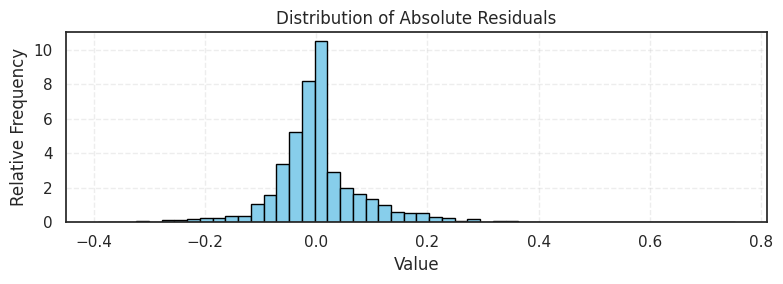

In [15]:
abs_diff = y - y_norm
rel_diff = (y - y_norm) / y_norm

print(f"Moyenne des valeurs normales : {y_norm.mean():.5f}")
print(f"Moyenne des valeurs réelles : {y.mean():.5f}")
print("")
print(f"Moyenne des résidus positifs (sous-estimation) : {abs_diff[abs_diff > 0].mean():.5f}")
print(f"Moyenne des résidus négatifs (sur-estimation) : {abs_diff[abs_diff < 0].mean():.5f}")
print("")
print(f"Moyenne des résidus relatifs positifs (sous-estimation) : {rel_diff[rel_diff > 0].mean():.5f}")
print(f"Moyenne des résidus relatifs négatifs (sur-estimation) : {rel_diff[rel_diff < 0].mean():.5f}")

plt.figure(figsize=(8, 3))
plt.hist(abs_diff, bins=50, color='skyblue', edgecolor='black', density=True)
plt.title('Distribution of Absolute Residuals')
plt.xlabel('Value')
plt.ylabel('Relative Frequency')
plt.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

## Comparaison avec les OLS

Pas possible directement car la formule n'est pas linéaire pour les paramètres de base (alpha, beta, etc.)

Il faudrait estimer des OLS pour chaque valeur des indicatrices p, mais cela ne garantit pas que les autres coefficients seront identiques pour chaque modèle.

Ou faire une estimation en 2 étapes : le modèle simple, prendre les coefficients, puis les utiliser dans le modèle complexe.
Ou, le modèle simple hors période électorale...

On voit que le modèle est désormais centré, avec des résidus moyens nuls. Il est nécessaire d'introduire une constante négative pour cela, qui ne fait pas vraiment sens : cela signifierait que la proportion de citations que reçoivent par défaut les nuances politiques est négative.

*NB: cela pourrait témoigner de relations non-linéaires, mais c'est une possibilité que nous n'avons pas envie d'explorer, car la norme de representativité conduit à supposer des relations proportionnelles.*

Par ailleurs, les résultats du modèle OLS sont incohérents.
D'une part, il prédit un nombre substantiel de proportions négatives.
D'autre part, il ne prédit aucun ensemble cohérent de proportions, sommant à 1 pour la période concernée, avec des écarts substantiels autour de cette valeur.

## Détermination des valeurs optimales respectant les contraintes de compositionnalité

In [22]:
vars = ["political_alignment", "na_share", "pres_votes_share", "r2_rank_1", "r2_rank_2", "government", "pres_poll_result",
        "inter_dum", "pre_3", "pre_2", "pre_1", "pre_0", "post_dum",
        outcome]
data_opt = model_data_no_journal[vars]
y_opt = model_data_no_journal[outcome]

In [23]:
y_pred = (
    alpha + 
    data_opt["inter_dum"] * (
        beta_inter * (1 - n*alpha - theta) * data_opt["na_share"] + 
        gamma_inter * (1 - n*alpha - theta) * data_opt["pres_votes_share"] +
        theta * data_opt["government"]) +
    data_opt["pre_3"] * (
        delta_pre_3 * (
            beta_inter * (1 - n*alpha - theta) * data_opt["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * data_opt["pres_votes_share"] +
            theta * data_opt["government"]) +
        (1 - delta_pre_3) * data_opt["pres_poll_result"]) +
    data_opt["pre_2"] * (
        delta_pre_2 * (
            beta_inter * (1 - n*alpha - theta) * data_opt["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * data_opt["pres_votes_share"] +
            theta * data_opt["government"]) +
        (1 - delta_pre_2) * data_opt["pres_poll_result"]) +
    data_opt["pre_1"] * (
        delta_pre_1 * (
            beta_inter * (1 - n*alpha - theta) * data_opt["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * data_opt["pres_votes_share"] +
            theta * data_opt["government"]) +
        (1 - delta_pre_1) * data_opt["pres_poll_result"]) +
    data_opt["pre_0"] * (
        delta_pre_0 * (
            beta_inter * (1 - n*alpha - theta) * data_opt["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * data_opt["pres_votes_share"] +
            theta * data_opt["government"]) +
        (1 - delta_pre_0) * data_opt["pres_poll_result"]) +
     data_opt["post_dum"] * (
         (1 - n*alpha - lambda_1 - lambda_2) * data_opt["pres_votes_share"] + 
         lambda_1 * data_opt['r2_rank_1'] + lambda_2 * data_opt['r2_rank_2'])
)

In [24]:
data_opt = model_data_no_journal[
    ["na_share", "pres_votes_share", "government", "inter_dum", "pre_3", "pre_2", "pre_1", "pre_0", "post_dum", "pres_poll_result", "r2_rank_1", "r2_rank_2"]
]
y_opt = model_data_no_journal[outcome]

def objective(params):
    alpha = params[0]
    beta_inter = params[1]
    gamma_inter = 1 - beta_inter
    theta = params[2]
    delta_pre_3, delta_pre_2, delta_pre_1, delta_pre_0 = params[3:7]
    lambda_1, lambda_2 = params[7:9]

    common_term = (
        beta_inter * (1 - n * alpha - theta) * data_opt["na_share"] +
        gamma_inter * (1 - n * alpha - theta) * data_opt["pres_votes_share"] +
        theta * data_opt["government"]
    )

    y_pred = (
        alpha +
        data_opt["inter_dum"] * common_term +
        data_opt["pre_3"] * (delta_pre_3 * common_term + (1 - delta_pre_3) * data_opt["pres_poll_result"]) +
        data_opt["pre_2"] * (delta_pre_2 * common_term + (1 - delta_pre_2) * data_opt["pres_poll_result"]) +
        data_opt["pre_1"] * (delta_pre_1 * common_term + (1 - delta_pre_1) * data_opt["pres_poll_result"]) +
        data_opt["pre_0"] * (delta_pre_0 * common_term + (1 - delta_pre_0) * data_opt["pres_poll_result"]) +
        data_opt["post_dum"] * (
            (1 - n * alpha - lambda_1 - lambda_2) * data_opt["pres_votes_share"] +
            lambda_1 * data_opt["r2_rank_1"] +
            lambda_2 * data_opt["r2_rank_2"]
        )
    )

    return root_mse(y_opt, y_pred)

# Initial guess for the 9 parameters: alpha, beta_inter, theta, delta_pre_3 to delta_pre_0, lambda_1, lambda_2
initial_guess = [0.01, 0.7, 0.2, 0.8, 0.7, 0.6, 0.5, 0.3, 0.2]

# Bounds: all between 0 and 1
bounds = [(0, 1)] * 9

result = minimize(objective, initial_guess, bounds=bounds, method='SLSQP')

if result.success:
    alpha_opt, beta_inter_opt, theta_opt, delta_pre_3, delta_pre_2, delta_pre_1, delta_pre_0, lambda_1_opt, lambda_2_opt = result.x
    gamma_inter_opt = 1 - beta_inter_opt

    print(f"Optimal alpha: {alpha_opt:.5f}")
    print(f"Optimal beta_inter: {beta_inter_opt:.5f}")
    print(f"Optimal gamma_inter: {gamma_inter_opt:.5f}")
    print(f"Optimal theta: {theta_opt:.5f}")
    print(f"Optimal delta_pre_3: {delta_pre_3:.5f}")
    print(f"Optimal delta_pre_2: {delta_pre_2:.5f}")
    print(f"Optimal delta_pre_1: {delta_pre_1:.5f}")
    print(f"Optimal delta_pre_0: {delta_pre_0:.5f}")
    print(f"Optimal lambda_1: {lambda_1_opt:.5f}")
    print(f"Optimal lambda_2: {lambda_2_opt:.5f}")
else:
    print("Optimization failed:", result.message)


Optimal alpha: 0.00000
Optimal beta_inter: 0.76584
Optimal gamma_inter: 0.23416
Optimal theta: 0.09373
Optimal delta_pre_3: 0.84044
Optimal delta_pre_2: 0.67373
Optimal delta_pre_1: 0.62590
Optimal delta_pre_0: 0.49225
Optimal lambda_1: 0.20377
Optimal lambda_2: 0.06137


Premier constat : la constante est éliminée, de sorte que certaines valeurs normales deviennent nulles, et que les résidus relatifs ne sont plus calculables.

Les autres valeurs ne sont pas si différentes des nôtres, et les performances du modèle à peine meilleures.

In [ ]:
cutoff = pd.Period('2012-06', freq='M')

data_opt = model_data[
    (model_data["month"] < cutoff) & 
    (model_data["journal"] == "Le Monde") &
    (model_data["political_alignment"].isin(['Right', 'Left']))
][["na_share", "pres_votes_share", "government"]]

y_opt = model_data[
    (model_data["month"] < cutoff) & 
    (model_data["journal"] == "Le Monde") &
    (model_data["political_alignment"].isin(['Right', 'Left']))
][outcome]

On obtient encore des résultats comparables si l'on restreint l'estimation au *Monde* avant juin 2012.

# 1. Ecarts à la norme de représentativité selon les nuances politiques

In [25]:
alpha = alpha_opt
beta_inter = beta_inter_opt
gamma_inter = gamma_inter_opt
theta = theta_opt
delta_pre_3 = delta_pre_3
delta_pre_2 = delta_pre_2
delta_pre_1 = delta_pre_1
delta_pre_0 = delta_pre_0
lambda_1 = lambda_1_opt
lambda_2 = lambda_2_opt

In [26]:
model_data_no_journal['y_norm'] = (
    alpha + 
    model_data_no_journal["inter_dum"] * (
        beta_inter * (1 - n*alpha - theta) * model_data_no_journal["na_share"] + 
        gamma_inter * (1 - n*alpha - theta) * model_data_no_journal["pres_votes_share"] +
        theta * model_data_no_journal["government"]) +
    model_data_no_journal["pre_3"] * (
        delta_pre_3 * (
            beta_inter * (1 - n*alpha - theta) * model_data_no_journal["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * model_data_no_journal["pres_votes_share"] +
            theta * model_data_no_journal["government"]) +
        (1 - delta_pre_3) * model_data_no_journal["pres_poll_result"]) +
    model_data_no_journal["pre_2"] * (
        delta_pre_2 * (
            beta_inter * (1 - n*alpha - theta) * model_data_no_journal["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * model_data_no_journal["pres_votes_share"] +
            theta * model_data_no_journal["government"]) +
        (1 - delta_pre_2) * model_data_no_journal["pres_poll_result"]) +
    model_data_no_journal["pre_1"] * (
        delta_pre_1 * (
            beta_inter * (1 - n*alpha - theta) * model_data_no_journal["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * model_data_no_journal["pres_votes_share"] +
            theta * model_data_no_journal["government"]) +
        (1 - delta_pre_1) * model_data_no_journal["pres_poll_result"]) +
    model_data_no_journal["pre_0"] * (
        delta_pre_0 * (
            beta_inter * (1 - n*alpha - theta) * model_data_no_journal["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * model_data_no_journal["pres_votes_share"] +
            theta * model_data_no_journal["government"]) +
        (1 - delta_pre_0) * model_data_no_journal["pres_poll_result"]) +
     model_data_no_journal["post_dum"] * (
         (1 - n*alpha - lambda_1 - lambda_2) * model_data_no_journal["pres_votes_share"] + 
         lambda_1 * model_data_no_journal['r2_rank_1'] + lambda_2 * model_data_no_journal['r2_rank_2'])
)

In [ ]:
model_data_no_journal['y_norm'] = y_norm

In [27]:
model_data_no_journal['abs_residuals'] = 100 * (model_data_no_journal[outcome] - model_data_no_journal['y_norm'])
model_data_no_journal['rel_residuals'] = 100 * (model_data_no_journal[outcome] - model_data_no_journal['y_norm']) / model_data_no_journal['y_norm']

In [28]:
plot_data = model_data_no_journal.copy()
plot_data['month'] = plot_data['month'].dt.to_timestamp()

alignment_groups = [
    (['Far left', 'Far right', 'Other'],
     {'Far left': 'crimson',
      'Far right': 'royalblue',
      'Other': 'forestgreen'}),
    (['Right', 'Left', 'Center'],
     {'Right': 'cornflowerblue',
      'Left': 'orchid',
      'Center': 'goldenrod'})]

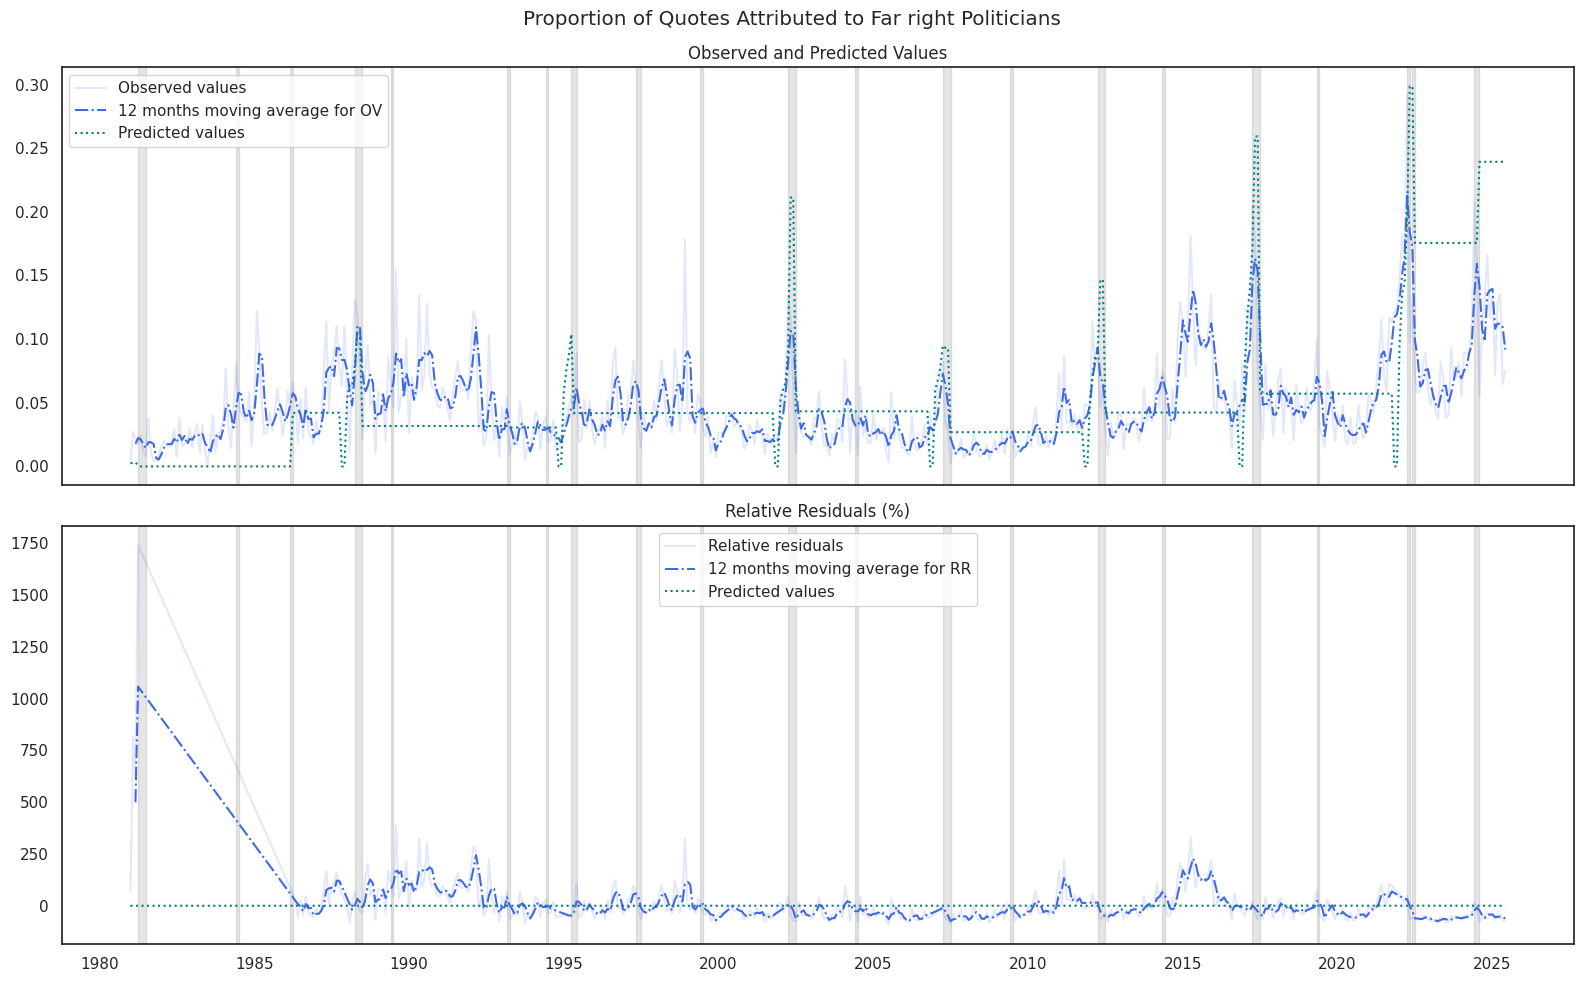

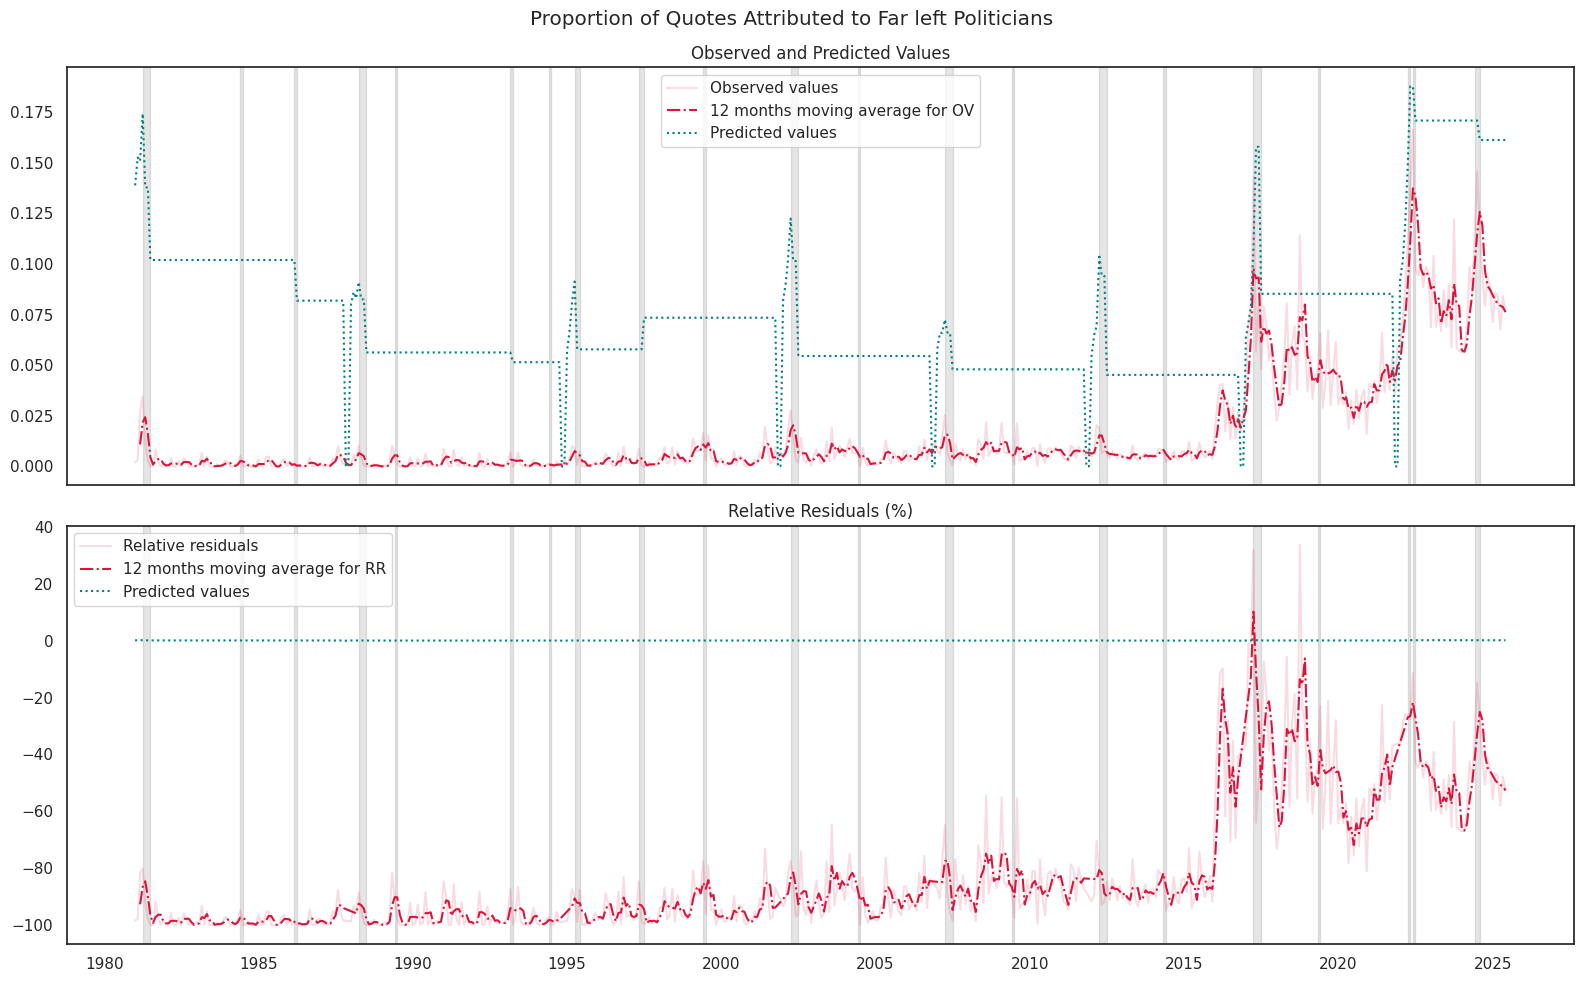

In [29]:
for alignment in ['Far right', 'Far left']:
    color = 'royalblue' if alignment == 'Far right' else 'crimson'
    subset_data = plot_data[plot_data['political_alignment'] == alignment].copy()
    subset_data['MA_observed'] = subset_data[outcome].rolling(window=3).mean()
    subset_data['MA_rel'] = subset_data['rel_residuals'].rolling(window=3).mean()

    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    sns.lineplot(data=subset_data, x='month', y=outcome, ax=axes[0], label='Observed values', alpha=0.15, color=color, linestyle='-')
    sns.lineplot(data=subset_data, x='month', y='MA_observed', ax=axes[0], label='12 months moving average for OV', color=color, linestyle='dashdot')
    sns.lineplot(data=subset_data, x='month', y='y_norm', ax=axes[0], label='Predicted values', color='teal', linestyle='dotted')
    axes[0].set_title("Observed and Predicted Values")
    axes[0].set_ylabel('')

    sns.lineplot(data=subset_data, x='month', y='rel_residuals', ax=axes[1], label='Relative residuals', alpha=0.15, color=color, linestyle='-')
    sns.lineplot(data=subset_data, x='month', y='MA_rel', ax=axes[1], label='12 months moving average for RR', color=color, linestyle='dashdot')
    sns.lineplot(data=subset_data, x='month', y='y_norm', ax=axes[1], label='Predicted values', color='teal', linestyle='dotted')
    axes[1].set_title("Relative Residuals (%)")
    axes[1].set_xlabel('')
    axes[1].set_ylabel('')

    add_shaded_periods(axes, main_elec_months, color='black', alpha=0.1)

    plt.suptitle(f"Proportion of Quotes Attributed to {alignment} Politicians")
    plt.tight_layout()
    plt.savefig(f"output/{alignment}_graph.png", dpi=300, bbox_inches='tight')
    plt.show()

Concernant spécifiquement l'extrême droite, on n'observe pas d'augmentation tendancielle des résidus relatifs, qui témoignerait d'une application de plus en plus laxiste de la norme de représentativité, dans un sens favorable.

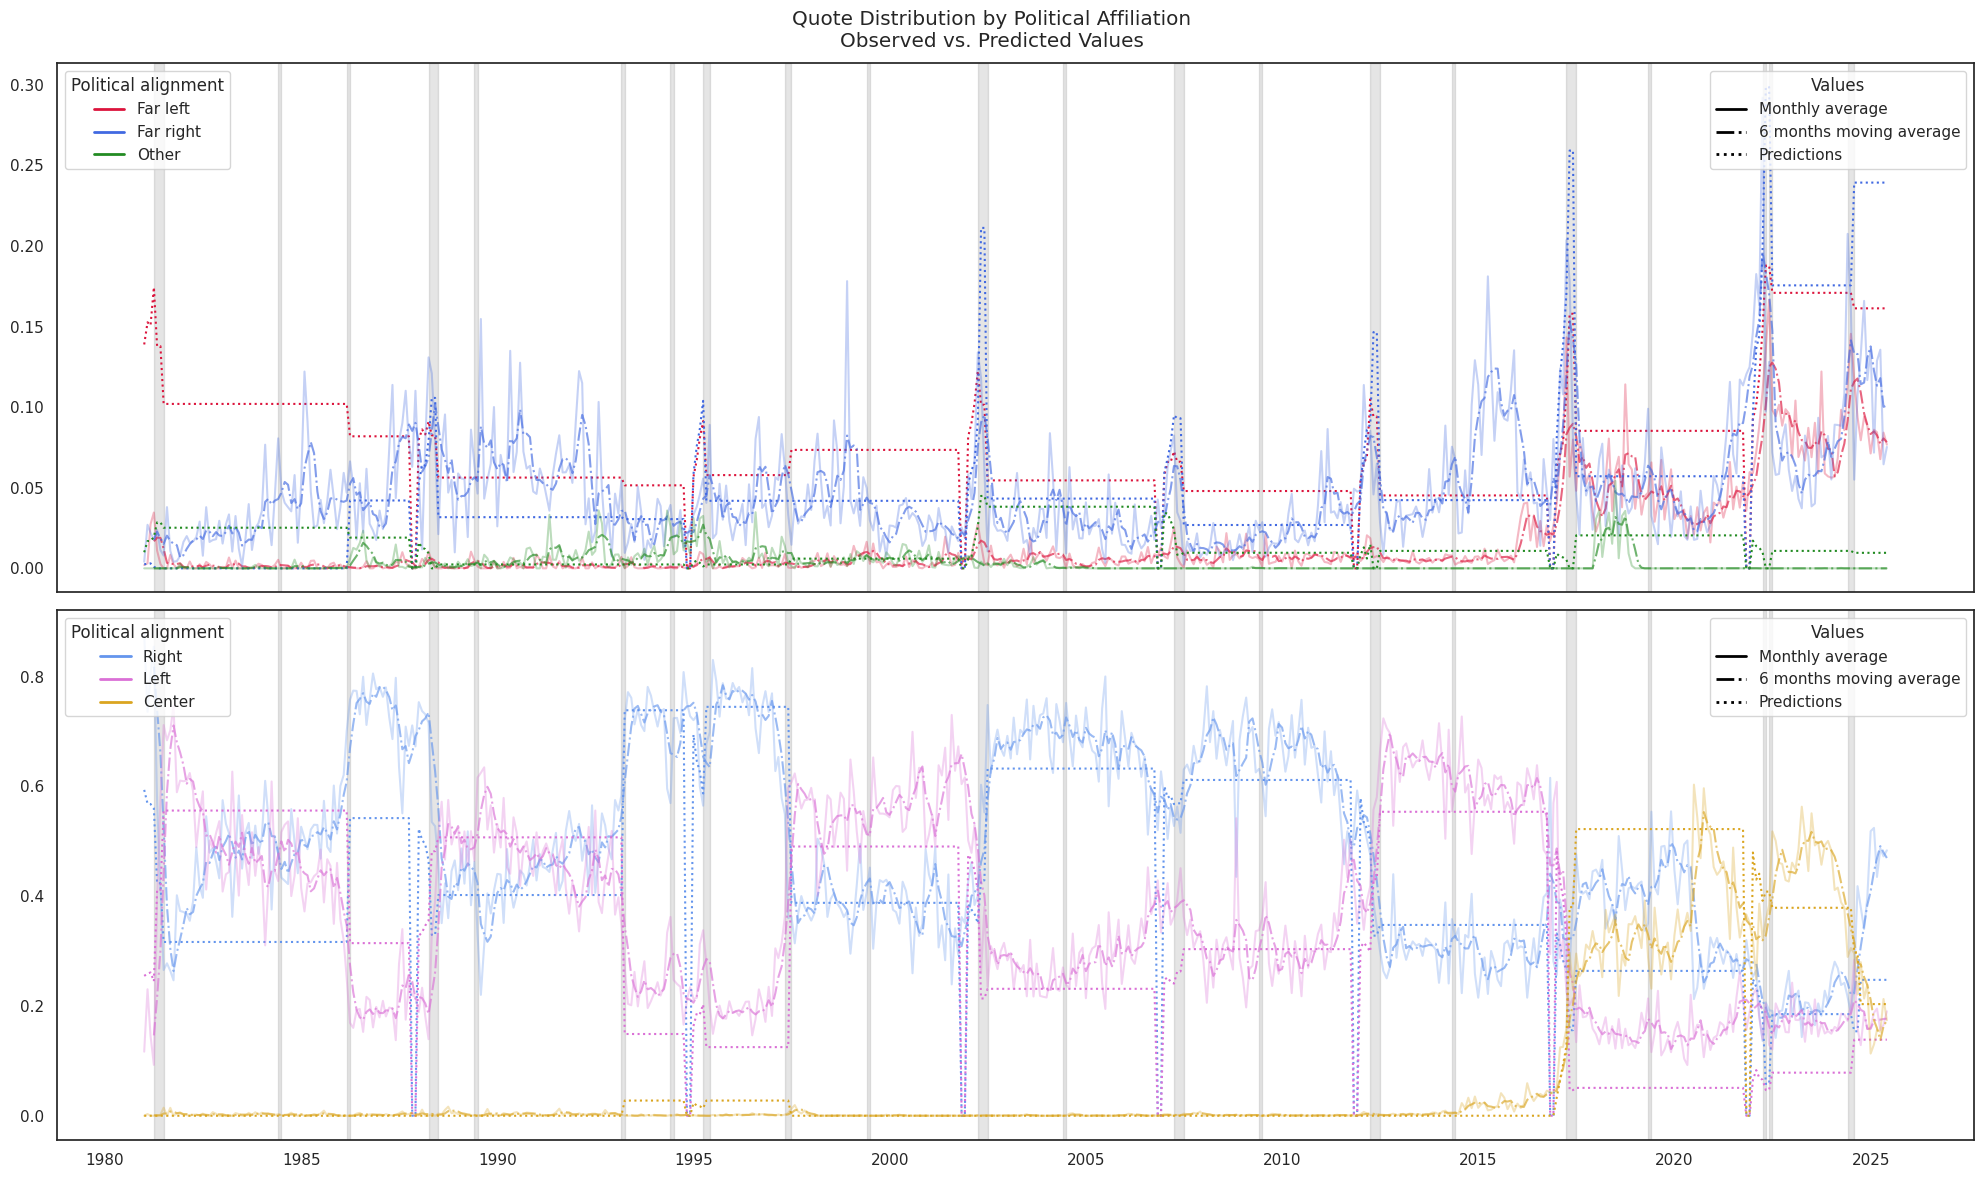

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(20, 12), sharex=True)

for ax, (political_alignments, colors) in zip(axes, alignment_groups):
    alignment_handles = []

    for alignment in political_alignments:
        subset_data = plot_data[plot_data['political_alignment'] == alignment].copy()
        subset_data['MA'] = subset_data[outcome].rolling(window=4).mean()
        
        ax.plot(subset_data['month'], subset_data[outcome], label=None,
                alpha=0.3, color=colors[alignment], linestyle='-')
        ax.plot(subset_data['month'], subset_data['MA'], label=None,
                alpha=0.65, color=colors[alignment], linestyle='dashdot')
        ax.plot(subset_data['month'], subset_data['y_norm'], label=None,
                alpha=1, color=colors[alignment], linestyle='dotted')
        
        alignment_handles.append(Line2D([0], [0], color=colors[alignment], lw=2, label=alignment))

    alignment_legend = ax.legend(handles=alignment_handles, title="Political alignment", loc="upper left")
    ax.add_artist(alignment_legend)

    line_type_handles = [
        Line2D([0], [0], color='black', lw=2, linestyle='-', label="Monthly average"),
        Line2D([0], [0], color='black', lw=2, linestyle='dashdot', label="6 months moving average"),
        Line2D([0], [0], color='black', lw=2, linestyle='dotted', label="Predictions")]
    ax.legend(handles=line_type_handles, title="Values", loc="upper right")

axes[-1].set_xlabel("")

add_shaded_periods(axes, main_elec_months, color='black', alpha=0.1)

plt.suptitle("Quote Distribution by Political Affiliation\nObserved vs. Predicted Values")
plt.tight_layout()
plt.savefig("output/nuances_val_graph.png", dpi=300, bbox_inches='tight')
plt.show()

1986 = changement de majorité et de gouvernement sans lien avec une élection présidentielle
1995 en particulier = le pic négatif pour la droite, et les pics positifs pour les autres partis, sont attendus. En période électorale, la couverture du parti dominant se réduit fatalement pour laisser de la place à ses opposants. Car la couverture médiatique devient seulement tirée par la compétition politique, plus par les enjeux institutionnels / de gouvernement.

In [ ]:
model_data_no_journal[
    (model_data_no_journal['political_alignment'] == 'Right') &
    (model_data_no_journal["month"] >= pd.Period('1994-09', freq='M')) &
    (model_data_no_journal["month"] < pd.Period('1995-09', freq='M'))][
    ['month', "na_share", "pres_votes_share", "r2_rank_1", "r2_rank_2", "government", "pres_poll_result", 'y_norm']]

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

for ax, (political_alignments, colors) in zip(axes, alignment_groups):
    alignment_handles = []

    for alignment in political_alignments:
        subset_data = plot_data[plot_data['political_alignment'] == alignment].copy()
        subset_data['MA'] = subset_data['rel_residuals'].rolling(window=6).mean()
        
        ax.plot(subset_data['month'], subset_data['rel_residuals'], label=None,
                alpha=0.2, color=colors[alignment], linestyle='-')
        ax.plot(subset_data['month'], subset_data['MA'], label=None,
                alpha=0.65, color=colors[alignment], linestyle='-.')
        ax.plot(subset_data['month'], [0] * len(subset_data), label=None,
                alpha=1, color='darkgray', linestyle=':')
        
        alignment_handles.append(Line2D([0], [0], color=colors[alignment], lw=2, label=alignment))

    alignment_legend = ax.legend(handles=alignment_handles, title="Political alignment", loc="upper left")
    ax.add_artist(alignment_legend)

    line_type_handles = [
        Line2D([0], [0], color='black', lw=2, linestyle='-', label="Monthly average"),
        Line2D([0], [0], color='black', lw=2, linestyle='-.', label="6 months moving average"),
        Line2D([0], [0], color='black', lw=2, linestyle=':', label="Predictions")
    ]
    ax.legend(handles=line_type_handles, title="Values", loc="upper right")

axes[-1].set_xlabel("")

add_shaded_periods(axes, main_elec_months, color='black', alpha=0.1)

plt.suptitle("Quote Distribution by Political Affiliation\nRelative Residuals (%)")
plt.tight_layout()
plt.savefig("output/nuances_res_graph.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

for ax, (political_alignments, colors) in zip(axes, alignment_groups):
    alignment_handles = []

    for alignment in political_alignments:
        subset_data = plot_data[plot_data['political_alignment'] == alignment].copy()
        subset_data['MA'] = subset_data['abs_residuals'].rolling(window=6).mean()
        
        ax.plot(subset_data['month'], subset_data['abs_residuals'], label=None,
                alpha=0.2, color=colors[alignment], linestyle='-')
        ax.plot(subset_data['month'], subset_data['MA'], label=None,
                alpha=0.65, color=colors[alignment], linestyle='-.')
        ax.plot(subset_data['month'], [0] * len(subset_data), label=None,
                alpha=1, color='darkgray', linestyle=':')
        
        alignment_handles.append(Line2D([0], [0], color=colors[alignment], lw=2, label=alignment))

    alignment_legend = ax.legend(handles=alignment_handles, title="Political alignment", loc="upper left")
    ax.add_artist(alignment_legend)

    line_type_handles = [
        Line2D([0], [0], color='black', lw=2, linestyle='-', label="Monthly average"),
        Line2D([0], [0], color='black', lw=2, linestyle='-.', label="6 months moving average"),
        Line2D([0], [0], color='black', lw=2, linestyle=':', label="Predictions")
    ]
    ax.legend(handles=line_type_handles, title="Values", loc="upper right")

axes[-1].set_xlabel("")

add_shaded_periods(axes, main_elec_months, color='black', alpha=0.1)

plt.suptitle("Quote Distribution by Political Affiliation\nAbsolute Residuals (%)")
plt.tight_layout()
plt.savefig("output/nuances_abs_graph.png", dpi=300, bbox_inches='tight')
plt.show()

Le résultat le plus flagrant est la présence de deux dynamiques non-capturées : 
- L'une pour l'extrême-droite entre 1983 et 1985. L'année 1984 correspond au premier succès du Front national lors d'une élection nationale. Or, il s'agit des européennes, dont les résultats ne sont pas intégrés notre modèle normatif. Lorsque l'on exclut la période correspondante, les MAPE du modèle *a priori* deviennent équivalente pour l'extrême droite et l'extrême gauche (mais avec des MRR toujours bien plus négatifs pour la seconde) (cf. *infra*).
- L'autre pour le centre entre 2007 et 2017. Ici, le décalage entre les comportements réels et prescrits est plus difficilement explicable. L'année 2007 est marquée par la percée de François Bayrou lors des élections présidentielles, qui arrive 3e avec 18,57 % des voix, et l'année 2017 par la victoire d'Emmanuel Macron à ces mêmes élections. Mais les résultats de ces dernières sont bien pris en compte par notre modèle normatif. Alors... ? Observons nous ici un fort engagement des rédactions en faveur du centre ? Ou cette impression résulte-t-elle de problèmes dans les données ?

On constate aussi l'existence d'une prime à la majorité pour les partis accédant au pouvoir, qui reçoivent toujours davantage de citations que prescrit pas notre modèle. Mais curieusement, l'ajout de la nuance politique du Premier ministre aux modèles estimés n'améliore pas leurs performances prédictives (cf. *infra*).

Enfin, aucun biais systématique n'apparaît dans la couverture médiatique des nuances politiques, sauf en défaveur de l'extrême gauche.

In [ ]:
summary_list = []

for alignment in model_data_no_journal['political_alignment'].unique():
    subset_data = model_data_no_journal[(model_data_no_journal['political_alignment'] == alignment) & (model_data_no_journal["month"] > pd.Period('1988-01', freq='M'))]
    y = subset_data[outcome]
    y_norm = subset_data['y_norm']
    mr = mean_r(y, y_norm)
    mrr = mean_rr(y, y_norm)
    mape = mean_ape(y, y_norm)
    rmspe = root_mse(y, y_norm)
    summary_list.append({
        'Political alignment': alignment,
        'MR': mr,
        'MRR': mrr,
        'MAPE': mape,
        'RMSPE': rmspe
    })

summary = pd.DataFrame(summary_list)
summary["Political alignment"] = pd.Categorical(summary["Political alignment"], categories=nuances_order, ordered=True)
summary.style.hide(axis=0)

*Tentative pour calculer la proportion des proportions de citations correctement prescrites...*
- *Correct prescriptions = proportion des citations prescrites correspondant à des citations réelles*
- *Excess prescriptions = proportion des citations prescrites excédant les citations réelles*
- *True missing = proportion des citations réelles non-prescrites par le modèle a priori*

In [ ]:
def compute_proportional_metrics(y_norm, y_true):
    y_norm = np.array(y_norm)
    y_true = np.array(y_true)
    
    # Initialize arrays
    TP = np.zeros_like(y_norm)
    TN = np.zeros_like(y_norm)
    FP = np.zeros_like(y_norm)
    FN = np.zeros_like(y_norm)
    
    # Calculate difference
    diff = y_norm - y_true
    
    # Case 1: y_norm - y_true = 0 (perfect prediction)
    perfect_mask = (diff == 0)
    TP[perfect_mask] = 1
    FP[perfect_mask] = 0
    FN[perfect_mask] = 0
    
    # Case 2: y_norm - y_true > 0 (over-prediction)
    over_mask = (diff > 0)
    TP[over_mask] = y_true[over_mask] / y_norm[over_mask]
    FP[over_mask] = diff[over_mask] / y_norm[over_mask]
    FN[over_mask] = 0
    
    # Case 3: y_norm - y_true < 0 (under-prediction)
    under_mask = (diff < 0)
    TP[under_mask] = 1
    FN[under_mask] = - diff[under_mask] / y_true[under_mask]
    FP[under_mask] = 0
    
    return {
        'TP': TP.mean(),
        'FP': FP.mean(),
        'FN': FN.mean()}

summary_list = []

for alignment in model_data_no_journal['political_alignment'].unique():
    subset_data = model_data_no_journal[model_data_no_journal['political_alignment'] == alignment]
    y = subset_data[outcome]
    y_norm = subset_data['y_norm']
    metrics = compute_proportional_metrics(y_norm, y)
    summary_list.append({
        'Political alignment': alignment,
        '% correct prescriptions': 100 * metrics['TP'],
        '% excess prescriptions': 100 * metrics['FP'],
        '% missing prescriptions': 100 * metrics['FN']})

summary = pd.DataFrame(summary_list)
summary["Political alignment"] = pd.Categorical(summary["Political alignment"], categories=nuances_order, ordered=True)
summary.style.hide(axis="index").format({col: "{:.2f}" for col in summary.columns[1:]})

# 2. Ecarts à la norme de représentativité selon les journaux

In [ ]:
model_data['y_norm'] = (
    alpha + 
    model_data["inter_dum"] * (
        beta_inter * (1 - n*alpha - theta) * model_data["na_share"] + 
        gamma_inter * (1 - n*alpha - theta) * model_data["pres_votes_share"] +
        theta * model_data["government"]) +
    model_data["pre_3"] * (
        delta_pre_3 * (
            beta_inter * (1 - n*alpha - theta) * model_data["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * model_data["pres_votes_share"] +
            theta * model_data["government"]) +
        (1 - delta_pre_3) * model_data["pres_poll_result"]) +
    model_data["pre_2"] * (
        delta_pre_2 * (
            beta_inter * (1 - n*alpha - theta) * model_data["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * model_data["pres_votes_share"] +
            theta * model_data["government"]) +
        (1 - delta_pre_2) * model_data["pres_poll_result"]) +
    model_data["pre_1"] * (
        delta_pre_1 * (
            beta_inter * (1 - n*alpha - theta) * model_data["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * model_data["pres_votes_share"] +
            theta * model_data["government"]) +
        (1 - delta_pre_1) * model_data["pres_poll_result"]) +
    model_data["pre_0"] * (
        delta_pre_0 * (
            beta_inter * (1 - n*alpha - theta) * model_data["na_share"] + 
            gamma_inter * (1 - n*alpha - theta) * model_data["pres_votes_share"] +
            theta * model_data["government"]) +
        (1 - delta_pre_0) * model_data["pres_poll_result"]) +
     model_data["post_dum"] * (
         (1 - n*alpha - lambda_1 - lambda_2) * model_data["pres_votes_share"] + 
         lambda_1 * model_data['r2_rank_1'] + lambda_2 * model_data['r2_rank_2'])
)
model_data['abs_residuals'] = 100 * (model_data[outcome] - model_data['y_norm'])
model_data['rel_residuals'] = 100 * (model_data[outcome] - model_data['y_norm']) / model_data['y_norm']

In [ ]:
summary = []

for journal in model_data['journal'].unique():
    subset_data = model_data[model_data['journal'] == journal]
    y = subset_data[outcome]
    y_norm = subset_data['y_norm']
    mr = mean_r(y, y_norm)
    mrr = mean_rr(y, y_norm)
    mape = mean_ape(y, y_norm)
    rmspe = root_mse(y, y_norm) / y.mean()
    summary.append({
        'Journal': journal,
        'MR': mr,
        'MRR': mrr,
        'MAPE': mape,
        'RMSPE': rmspe})

pd.DataFrame(summary).style.hide(axis=0)

Trois groupes de journaux apparaissent :
- Le Figaro et Le Monde respectent le plus la norme de représentativité
- La Croix et Libération la respectent un peu moins
- Médiapart s'en écarte plus franchement

In [ ]:
results = []

for journal in model_data['journal'].unique():
    for alignment in model_data['political_alignment'].unique():
        subset_data = model_data[(model_data['journal'] == journal) & (model_data['political_alignment'] == alignment)]
        y = subset_data[outcome]
        y_norm = subset_data['y_norm']
        mr = mean_r(y, y_norm)
        mrr = mean_rr(y, y_norm)
        mape = mean_ape(y, y_norm)
        rmspe = root_mse(y, y_norm)
        results.append({
            'alignment': alignment,
            'journal': journal,
            'MR': mr,
            'MRR': mrr,
            'MAPE': mape,
            'RMSPE': rmspe})

results = pd.DataFrame(results)
results["alignment"] = pd.Categorical(results["alignment"], categories=nuances_order, ordered=True)
results = results.sort_values(["alignment", "journal"])
results = results.set_index(["alignment", "journal"])
results.index.names = ["Political Alignment", "Journal"]

results.style.format("{:.4f}")

Le traitement du centre par La Croix et de la gauche par Libération semble responsable de leur déviation supérieure par rapport au Monde et au Figaro. Médiapart se distingue en citant davantage l'extrême gauche, mais plus encore l'extrême droite.

In [ ]:
plot_data = model_data.copy()
plot_data['month'] = plot_data['month'].dt.to_timestamp()

colors = {
    'Le Figaro': 'goldenrod',
    'Libération': 'limegreen',
    'Le Monde': 'orchid',
    'La Croix': 'skyblue',
    'Médiapart': 'crimson'}

alignments = [
    "Far right",
    "Right",
    "Center",
    "Left",
    "Far left"]

n_alignments = len(alignments)

In [ ]:
fig, axes = plt.subplots(n_alignments, 1, figsize=(16, 4 * n_alignments), sharex=True)

for i, alignment in enumerate(alignments):
    ax = axes[i]
    subset_data = plot_data[plot_data['political_alignment'] == alignment]

    for journal in subset_data['journal'].unique():
        if journal == 'Médiapart': continue
        sub_subset_data = subset_data[subset_data['journal'] == journal].copy()
        sub_subset_data['MA'] = sub_subset_data[outcome].rolling(window=12).mean()
        ax.plot(sub_subset_data['month'], sub_subset_data[outcome], label=journal,
                alpha=0.7, color=colors[journal], linestyle='-')

    ax.plot(subset_data['month'], subset_data['y_norm'], color='black', alpha=0.8, linestyle='dotted')
    ax.set_title(f"{alignment}")
    ax.legend()

add_shaded_periods(axes, main_elec_months, color='black', alpha=0.1)

plt.suptitle("""
Quote Distribution by Political Affiliation and Journal\n
Observed vs. Predicted Values
""")
plt.tight_layout()
plt.savefig("output/journals_val_graph.png", dpi=300, bbox_inches='tight')
plt.show()

Médiapart est exclu des graphs car ses données semblent assez erratiques jusqu'en 2012 : le nombre d'articles publiés est probablement faible, ce qui conduit à atteindre régulièrement des proportions de 1 pour certaines nuances politiques.

On retrouve de manière plus visible que dans le tableau les différences éditoriales auxquelles on pouvait s'attendre : le Figaro et la Croix couvrent davantage la droite que le Monde et Libération, et inversement pour la gauche et l'extrême gauche. Concernant l'extrême droite, aucune différence flagrante n'apparaît.

In [ ]:
fig, axes = plt.subplots(n_alignments, 1, figsize=(16, 4 * n_alignments), sharex=True)

for i, alignment in enumerate(alignments):
    ax = axes[i]
    subset_data = plot_data[plot_data['political_alignment'] == alignment]

    for journal in subset_data['journal'].unique():
        sub_subset_data = subset_data[subset_data['journal'] == journal].copy()
        sub_subset_data['MA'] = sub_subset_data['rel_residuals'].rolling(window=12).mean()
        ax.plot(sub_subset_data['month'], sub_subset_data['MA'], label=journal,
                alpha=0.7, color=colors[journal], linestyle='-')

    ax.plot(subset_data['month'], subset_data['y_norm'], color='black', alpha=0.8, linestyle='dotted')
    ax.set_title(f"{alignment}")
    ax.legend()

add_shaded_periods(axes, main_elec_months, color='black', alpha=0.1)

plt.suptitle("""
Quote Distribution by Political Affiliation and Journal\n
Relative Residuals (%) - 12 months moving averages
""")
plt.tight_layout()
plt.savefig("output/journals_res_graph.png", dpi=300, bbox_inches='tight')
plt.show()

# 3. Work in progress / Régression des résidus

In [ ]:
model = smf.ols(f"abs_residuals ~ political_alignment - 1", 
                data=model_data_no_journal).fit(cov_type='HC3')

y = model_data_no_journal[outcome]
y_pred = model.predict(model_data_no_journal)
y_norm = model_data_no_journal['y_norm']

r2 = r2_score(y_norm, y_pred)
print(f"R2: {100*r2:.2f}%")

params = model.params.rename("coef").to_frame()
pvalues = model.pvalues.rename("pval").to_frame()
results = pd.merge(params, pvalues, left_index=True, right_index=True)
results = results[results['pval'] <= 0.1]
results.style

In [ ]:
X = pd.get_dummies(model_data_no_journal['political_alignment'], prefix='alignment')
X = X.drop(columns='alignment_Other')
X = X.astype(float)
X = sm.add_constant(X)
model = sm.OLS(y_norm, X).fit(cov_type='HC3')

y_pred = model.predict(X)
r2 = r2_score(y_norm, y_pred)
print(f"R2: {100*r2:.2f}%")

params = model.params.rename("coef").to_frame()
pvalues = model.pvalues.rename("pval").to_frame()
results = pd.merge(params, pvalues, left_index=True, right_index=True)
results = results[results['pval'] <= 0.1]
results.style

In [ ]:
# mais revient juste à calculer la moyenne des résidus par orientation politique (en l'absence de constante)
model_data_no_journal['y_norm'] = y_norm
model_data_no_journal[model_data_no_journal['political_alignment'] == "Center"]['y_norm'].mean()
# ou en la moyenne des résidus retranchée par orientation retranchée de la moyenne globale des résidus (en présence d'une constante) ?
# Pas exactement semble-t-il...
model_data_no_journal[model_data_no_journal['political_alignment'] == "Center"]['y_norm'].mean() - (y-y_norm).mean()